# Lab 1: NumPy for Cat and Dog Faces

In this notebook, you will treat **cat and dog face images** as NumPy arrays and build a small hand-crafted feature matrix.

This version focuses on core NumPy image operations and keeps the workflow concrete:

- load an image into a NumPy array
- crop and flip with slicing
- normalize to `[0, 1]`
- convert RGB to grayscale
- compute summaries with `axis=`
- apply a small filter with a kernel and matrix multiplication
- flatten an image into one vector
- engineer features with `np.concatenate(...)` and `np.apply_along_axis(...)`
- stack features into a feature matrix for later machine learning work

**Dataset assumption**

Use the curated cat-and-dog-faces dataset extracted into:

`data/`

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from lab_utils.visualization import (
    plot_feature_vector,
    show_image_gallery,
)

# Safe project root (works in scripts + notebooks)
try:
    PROJECT_ROOT = Path(__file__).resolve().parent
except NameError:
    PROJECT_ROOT = Path.cwd()

DATA_ROOT = PROJECT_ROOT / "data"

LABELS = ("cat", "dog")
LABEL_TO_INDEX = {"cat": 0, "dog": 1}

IMAGE_EXTENSIONS = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")

SEED = 1234

def label_from_path(path: Path) -> str:
    label = path.parent.name
    if label not in LABEL_TO_INDEX:
        raise ValueError(f"Unexpected label folder: {path}")
    return label


def load_preview_image(path: Path) -> np.ndarray:
    with Image.open(path) as image:
        return np.asarray(image.convert("RGB"))


def list_image_paths(label: str) -> list[Path]:
    label_dir = DATA_ROOT / label
    paths = []
    for pattern in IMAGE_EXTENSIONS:
        paths.extend(label_dir.glob(pattern))
    return sorted(paths)

def shuffled_paths(paths: list[Path], seed_offset: int = 0) -> list[Path]:
    rng = np.random.default_rng(SEED + seed_offset)
    indices = rng.permutation(len(paths))
    return [paths[int(idx)] for idx in indices]

def sample_paths(paths: list[Path], count: int, seed_offset: int) -> list[Path]:
    ordered = shuffled_paths(paths, seed_offset=seed_offset)
    return ordered[: min(count, len(ordered))]


def sample_per_class(paths: list[Path], n_per_class: int, seed_offset: int = 0) -> list[Path]:
    sampled = []
    for label_index, label in enumerate(LABELS):
        label_paths = [path for path in paths if label_from_path(path) == label]
        sampled.extend(sample_paths(label_paths, n_per_class, seed_offset + 50 * label_index))
    return sampled

def split_train_test(paths: list[Path], train_ratio: float = 0.7, seed_offset: int = 0):
    shuffled = shuffled_paths(paths, seed_offset)
    split_idx = int(len(shuffled) * train_ratio)
    return shuffled[:split_idx], shuffled[split_idx:]


# Check dataset exists
expected = [
    DATA_ROOT / "cat",
    DATA_ROOT / "dog",
]
if not all(path.exists() for path in expected):
    raise FileNotFoundError(
        f"Dataset not found at {DATA_ROOT}. Expected 'cat' and 'dog' folders."
    )


# Load all paths
cat_paths = list_image_paths("cat")
dog_paths = list_image_paths("dog")
cat_dog_paths = cat_paths + dog_paths

# Split per class (7:3)
cat_train, cat_test = split_train_test(cat_paths, 0.7, seed_offset=0)
dog_train, dog_test = split_train_test(dog_paths, 0.7, seed_offset=100)

# Combine
train_paths = cat_train + dog_train
test_paths = cat_test + dog_test

print(f"Using dataset from: {DATA_ROOT}")
print(f"Found {len(cat_paths)} cat images")
print(f"Found {len(dog_paths)} dog images")

if len(cat_paths) == 0 or len(dog_paths) == 0:
    raise ValueError("No images found. Check folder paths or file extensions.")

Using dataset from: d:\lab-1-numpy-104240199-creator\data
Found 10 cat images
Found 10 dog images


### Visual Helper: Preview the Faces Dataset

Before starting the TODOs, look at a few cat and dog face images from the student-specific subset.


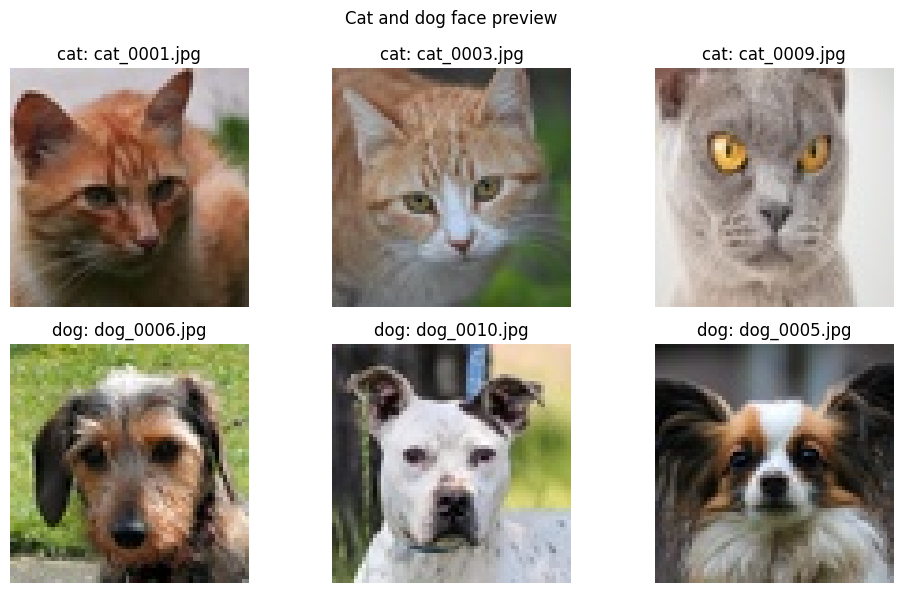

In [2]:
preview_paths = sample_per_class(cat_dog_paths, n_per_class=3, seed_offset=10)
preview_images = [load_preview_image(path) for path in preview_paths]
preview_titles = [f"{label_from_path(path)}: {path.name}" for path in preview_paths]
show_image_gallery(
    preview_images,
    titles=preview_titles,
    ncols=3,
    figsize=(10, 6),
    suptitle="Cat and dog face preview",
)
plt.show()


## Question 1: Load one image into a NumPy array

Write a function that:

- opens one file from disk
- converts it to RGB
- returns an `H x W x C` NumPy array

This is the starting point for every later NumPy operation in the lab.


shape: (64, 64, 3)
dtype: uint8
min/max: 0 225


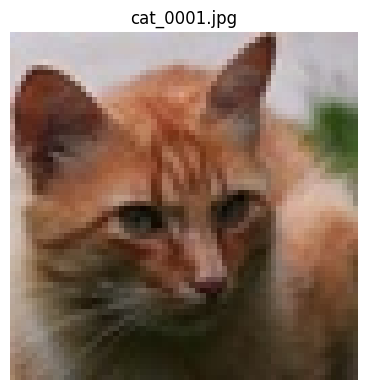

In [3]:
def load_image_np(path: Path) -> np.ndarray:
    img = Image.open(path) # open image file
    img_convert_rgb = img.convert("RGB") # convert image to RGB 
    res =  np.array(img_convert_rgb) # convert image to numpy array
    
    return res # return the result 

sample_path = cat_paths[0]
sample_image = load_image_np(sample_path)
print("shape:", sample_image.shape)
print("dtype:", sample_image.dtype)
print("min/max:", sample_image.min(), sample_image.max())
show_image_gallery([sample_image], titles=[sample_path.name], ncols=1, figsize=(4, 4))
plt.show()


## Question 2: Crop the image with slicing

Implement a centered square crop. Keep the crop size at `48 x 48` for the rest of the lab so the crop is visible and later operations stay consistent.


cropped shape: (56, 48, 3)


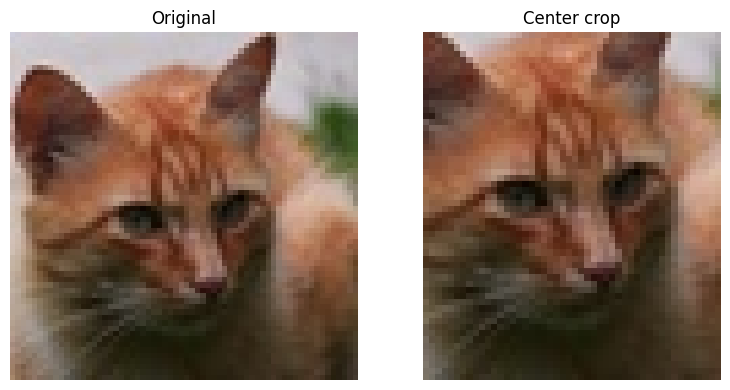

In [ ]:
def center_crop(image: np.ndarray, crop_size: int = 48) -> np.ndarray:
    # Get the height and width of the image
    height = image.shape[0]
    width = image.shape[1]

    # Find the center point for the image 
    middle_height = height // 2
    height_start = middle_height - (crop_size // 2)
    height_end = height_start + crop_size 
    # Calculate where the crop should start and end
    middle_width = width // 2
    width_start = middle_width - (crop_size // 2)
    width_end = width_start + crop_size 
    
    # Use slicing to crop the image
    new_image = image[int(height_start) : int(height_end), int(width_start) : int(width_end), :]

    return new_image


cropped_image = center_crop(sample_image, crop_size=48)
print("cropped shape:", cropped_image.shape)
show_image_gallery(
    [sample_image, cropped_image],
    titles=["Original", "Center crop"],
    ncols=2,
    figsize=(8, 4),
)
plt.show()


## Question 3: Flip the crop horizontally

Mirror the cropped image from left to right using slicing only.


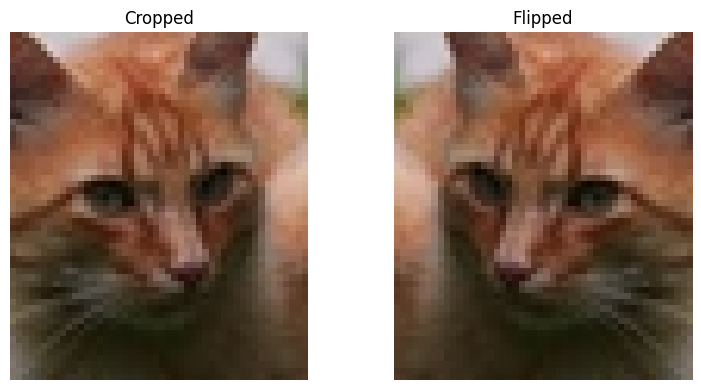

In [5]:
def flip_horizontal(image: np.ndarray) -> np.ndarray:
    new_image = image[:, ::-1, :] # from the basic_notebook.ipynb 
    return new_image



flipped_image = flip_horizontal(cropped_image)
show_image_gallery(
    [cropped_image, flipped_image],
    titles=["Cropped", "Flipped"],
    ncols=2,
    figsize=(8, 4),
)
plt.show()


## Question 4: Normalize pixels to `[0, 1]`

Convert the cropped RGB image from unsigned integers into `float32` values in the range `[0, 1]`.


Before: uint8 0 225
After : float32 0.0 0.88235295


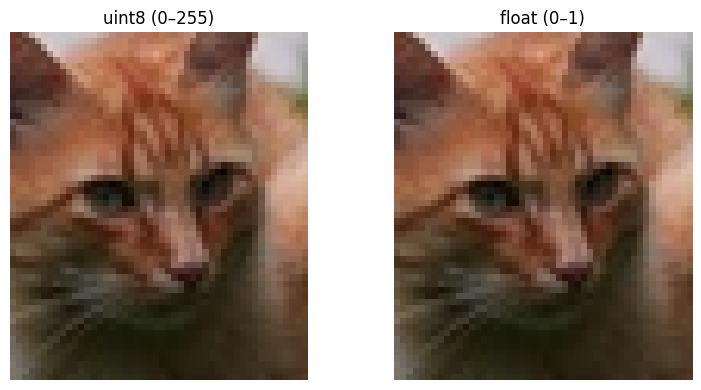

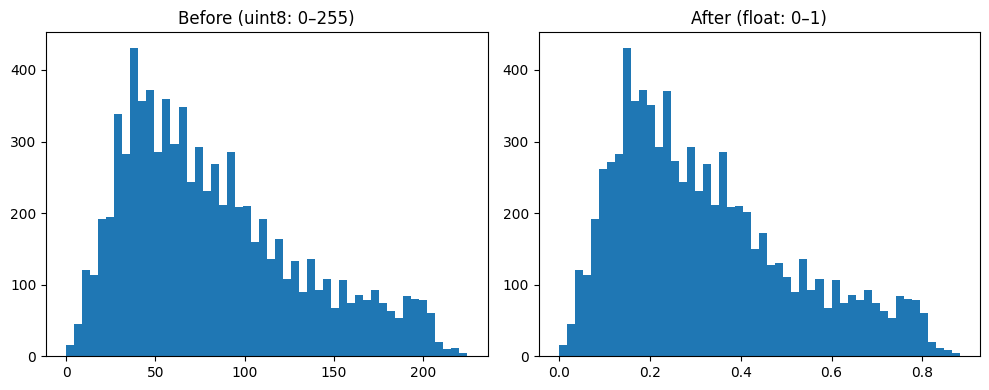

In [6]:
def normalize_01(image: np.ndarray) -> np.ndarray:
    float_image = image.astype(np.float32)

    normalized_image = float_image / 255.0

    return normalized_image


def show_histograms(uint8_img, float_img):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.hist(uint8_img.ravel(), bins=50)
    plt.title("Before (uint8: 0–255)")

    plt.subplot(1, 2, 2)
    plt.hist(float_img.ravel(), bins=50)
    plt.title("After (float: 0–1)")

    plt.tight_layout()
    plt.show()

sample_float = normalize_01(cropped_image)

# 1. Side-by-side image (Both image will look the same)
show_image_gallery(
    [cropped_image, sample_float],
    titles=["uint8 (0–255)", "float (0–1)"],
    ncols=2,
    figsize=(8, 4),
)

# 2. Stats
print("Before:", cropped_image.dtype, cropped_image.min(), cropped_image.max())
print("After :", sample_float.dtype, sample_float.min(), sample_float.max())

# 3. Histogram
show_histograms(cropped_image, sample_float)

plt.show()


## Question 5: Convert RGB to grayscale

Turn the normalized RGB image into a single grayscale array using standard RGB weights 

$GREY = 0.299 \cdot R + 0.587 \cdot G + 0.114 \cdot B$.


gray shape: (56, 48)
gray dtype: float32


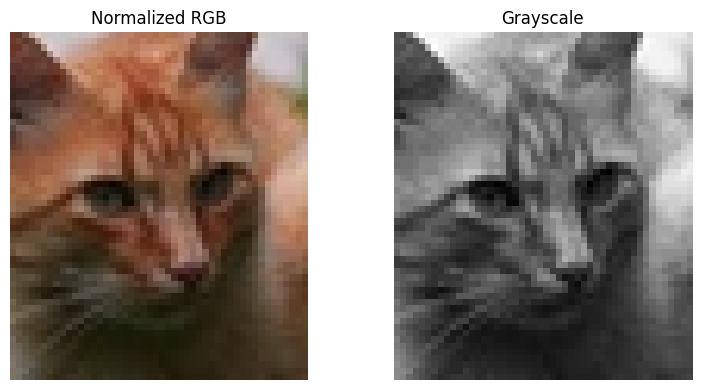

In [7]:
def rgb_to_gray(image_float: np.ndarray) -> np.ndarray:
    red = image_float[:, :, 0]  # Red channel
    green = image_float[:, :, 1] # Green channel
    blue = image_float[:, :, 2]  # Blue channel

    #Combine them follow the formula above to get the grayscale image
    gray_image = 0.299 * red + 0.587 * green + 0.114 * blue

    return gray_image

sample_gray = rgb_to_gray(sample_float)
print("gray shape:", sample_gray.shape)
print("gray dtype:", sample_gray.dtype)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_float)
axes[0].set_title("Normalized RGB")
axes[0].axis("off")
axes[1].imshow(sample_gray, cmap="gray")
axes[1].set_title("Grayscale")
axes[1].axis("off")
fig.tight_layout()
plt.show()


## Question 6: Use `axis=` to summarize channels

Compute one mean value per color channel with `axis=(0, 1)`, then choose the brightest channel with `np.argmax(...)`.


channel means: [0.42935798 0.31144747 0.23579134]
brightest channel: red


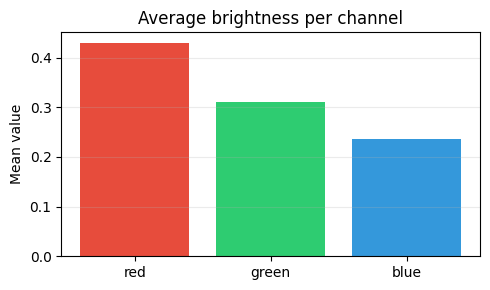

In [8]:
CHANNEL_NAMES = np.array(["red", "green", "blue"])


def channel_summary(image_float: np.ndarray) -> tuple[np.ndarray, int]:
    # Calculate the mean for each color channel  
    channel_means = np.mean(image_float, axis=(0,1))

    # Find the index of the highest value in the channel_means array 
    brightest_channel = np.argmax(channel_means)

    return channel_means, brightest_channel


sample_channel_means, sample_brightest = channel_summary(sample_float)
print("channel means:", sample_channel_means)
print("brightest channel:", CHANNEL_NAMES[sample_brightest])
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(CHANNEL_NAMES, sample_channel_means, color=["#E74C3C", "#2ECC71", "#3498DB"])
ax.set_title("Average brightness per channel")
ax.set_ylabel("Mean value")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()


## Question 7: Apply a filter with a kernel and matrix multiplication

Implement a tiny 2D convolution on the grayscale image. At each location:

1. take a `3 x 3` patch
2. flatten the patch and kernel
3. multiply them with `@`

Use the Laplacian kernel from the setup cell.


filtered shape: (54, 46)


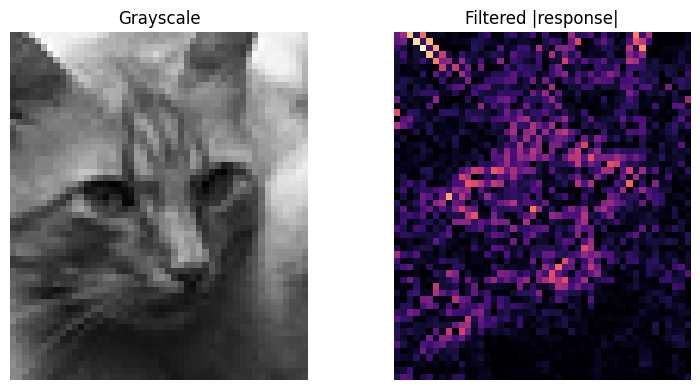

In [9]:
EDGE_KERNEL = np.array(
    [
        [0, 1, 0],
        [1, -4, 1],
        [0, 1, 0],
    ],
    dtype=np.float32,
)


def convolve2d_matmul(image_gray: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    #Get dimensions of the image and the kernel 
    image_height = image_gray.shape[0]
    image_weight = image_gray.shape[1]

    kernel_height = kernel.shape[0]
    kernel_weight = kernel.shape[1]

    # Calculate the size of the output image
    result_height = image_height - kernel_height + 1
    result_weight = image_weight - kernel_weight + 1

    # Create an empty array of zeros to store the results 
    result = np.zeros((result_height, result_weight))

    # Flatten the kernel into a 1D for matrix multiplication 
    kernel_flat = kernel.flatten()

    # Slide the kernel over the image using two loops 
    for i in range(result_height): 
        for j in range(result_weight):
            patch = image_gray[i:i+kernel_height, j:j+kernel_weight]
            patch_flat = patch.flatten()
            result[i,j] = patch_flat @ kernel_flat

    return result


sample_filtered = convolve2d_matmul(sample_gray, EDGE_KERNEL)
print("filtered shape:", sample_filtered.shape)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_gray, cmap="gray")
axes[0].set_title("Grayscale")
axes[0].axis("off")
axes[1].imshow(np.abs(sample_filtered), cmap="magma")
axes[1].set_title("Filtered |response|")
axes[1].axis("off")
fig.tight_layout()
plt.show()


## Question 8: Flatten one image into one vector

Take the grayscale crop and turn it into a one-dimensional vector.


original shape: (56, 48)
flat shape: (2688,)


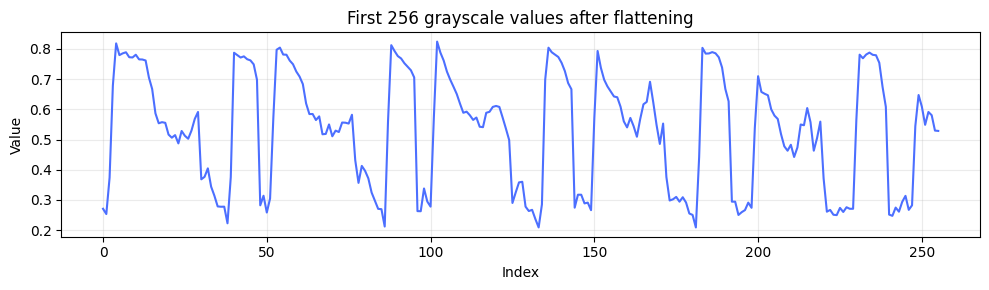

In [10]:
def flatten_image(image: np.ndarray) -> np.ndarray:
    flatten_image = image.reshape(-1) # flatten array from numpy.ipynb (Dr.Cuong)
    return flatten_image


sample_flat = flatten_image(sample_gray)
print("original shape:", sample_gray.shape)
print("flat shape:", sample_flat.shape)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(sample_flat[:256], color="#4C6FFF")
ax.set_title("First 256 grayscale values after flattening")
ax.set_xlabel("Index")
ax.set_ylabel("Value")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## Question 9: Engineer a feature vector with `concatenate` and `apply`

Build one hand-crafted feature vector that combines:

- RGB means
- RGB standard deviations
- the brightest channel index
- the mean and standard deviation of the filtered response
- one summary from `np.apply_along_axis(...)`

Use `np.concatenate(...)` to join the pieces.


feature shape: (10,)


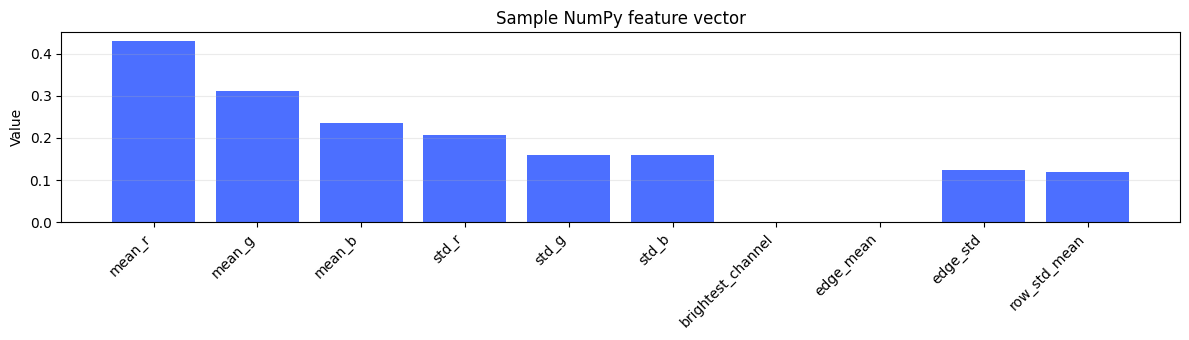

In [11]:
FEATURE_NAMES = [
    "mean_r",
    "mean_g",
    "mean_b",
    "std_r",
    "std_g",
    "std_b",
    "brightest_channel",
    "edge_mean",
    "edge_std",
    "row_std_mean",
]


def extract_features(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    cropped = center_crop(image, crop_size=48)
    image_float = normalize_01(cropped)
    gray = rgb_to_gray(image_float)
    channel_means, brightest_channel = channel_summary(image_float)
    channel_stds = image_float.std(axis=(0, 1)).astype(np.float32)
    filtered = convolve2d_matmul(gray, kernel)
    row_std_profile = np.apply_along_axis(np.std, 1, gray)

    edge_mean = np.array([filtered.mean()])
    edge_std = np.array([filtered.std()])
    row_std_mean = np.array([row_std_profile.mean()])

    brightest_channel_arr = np.array([brightest_channel])

    feature_list = [channel_means, channel_stds, brightest_channel_arr, edge_mean, edge_std, row_std_mean]

    feature_vector = np.concatenate(feature_list).astype(np.float32)

    return feature_vector


sample_features = extract_features(sample_image, EDGE_KERNEL)
print("feature shape:", sample_features.shape)
fig, ax = plot_feature_vector(sample_features, FEATURE_NAMES, title="Sample NumPy feature vector")
plt.show()


## Question 10: Build and inspect a feature matrix

Apply your feature function to the small balanced train/test subsets from the face dataset.

Tasks:

1. build one feature matrix for the train images and one for the test images
2. return the matching integer labels
3. print the resulting shapes
4. compute an overall feature mean with `axis=0`
5. visualize the feature matrix and the average feature vector


X_train shape: (14, 10)
y_train shape: (14,)
X_test shape: (6, 10)
y_test shape: (6,)
train class counts: [7 7]
test class counts: [3 3]
overall train feature mean shape: (10,)


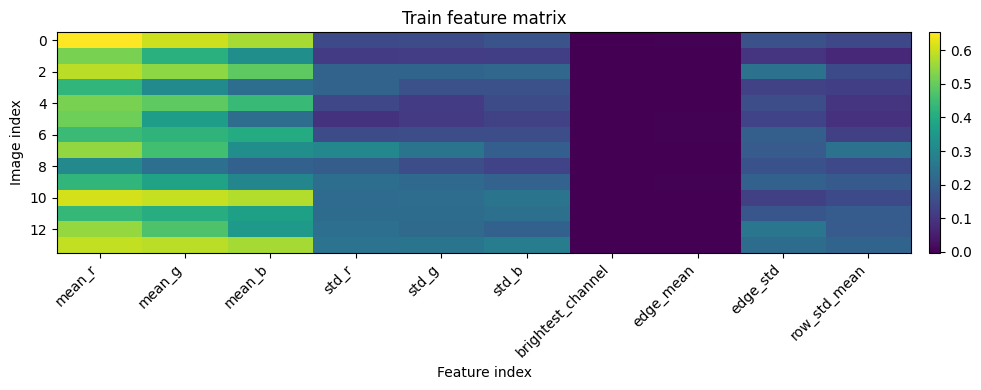

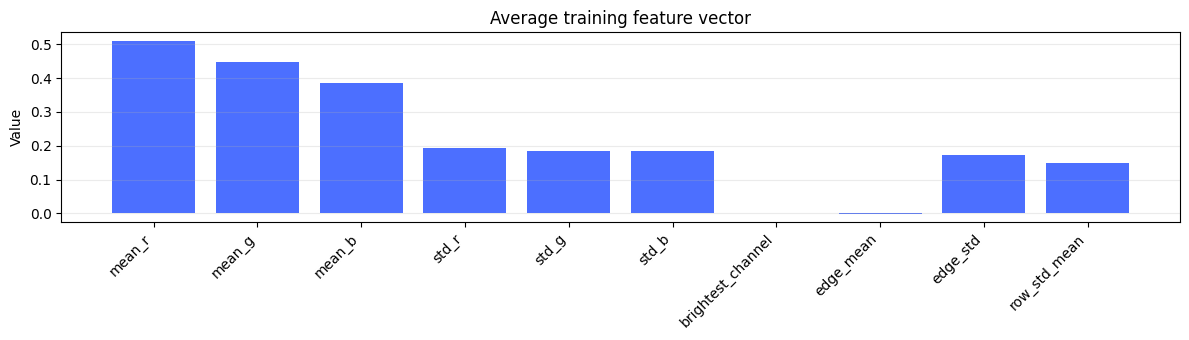

In [13]:
def build_feature_matrix(paths: list[Path], kernel: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    # Count how many images we have in total 
    n_images = len(paths)
    
    n_features = len(extract_features(load_image_np(paths[0]), kernel))

    # Create an empty feature matrix X 
    X = np.zeros((n_images, n_features), dtype=np.float32) 
    
    # Create an empty label vector  y
    y = np.zeros(n_images, dtype=np.int64)  

    # Go through every image path one by one 
    index = 0
    for path in paths:
        # Load the image and extract features  
        img = load_image_np(path)
        features = extract_features(img, kernel)

        # Place the 10 features into the correct row of our big table X
        X[index, :] = features
        
        # Find the label and convert to 0/1 
        label_name = label_from_path(path)
        y[index] = LABEL_TO_INDEX[label_name]

        index = index + 1

    return X, y


X_train, y_train = build_feature_matrix(train_paths, EDGE_KERNEL)
X_test, y_test = build_feature_matrix(test_paths, EDGE_KERNEL)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("train class counts:", np.bincount(y_train, minlength=2))
print("test class counts:", np.bincount(y_test, minlength=2))

train_feature_mean = X_train.mean(axis=0)
print("overall train feature mean shape:", train_feature_mean.shape)

fig, ax = plt.subplots(figsize=(10, 4))
image = ax.imshow(X_train, aspect="auto", cmap="viridis")
ax.set_title("Train feature matrix")
ax.set_xlabel("Feature index")
ax.set_ylabel("Image index")
ax.set_xticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha="right")
fig.colorbar(image, ax=ax, fraction=0.03, pad=0.02)
fig.tight_layout()
plt.show()

fig, ax = plot_feature_vector(train_feature_mean, FEATURE_NAMES, title="Average training feature vector")
plt.show()


## Reflection

Answer these short questions in your own words:

1. Why is it useful to keep the crop size fixed before feature extraction?
2. What does `axis=(0, 1)` mean when you compute channel means on an image?
3. What information does the small edge filter capture that plain RGB means miss?
4. Why does flattening help some operations but also lose spatial structure?


My Answer : 
1. In my opinion, it is useful due to it makes all data are in the same structure, from that NumPy can stack them into one big table for computer to learn, compute or calculate easy

2.  Well, it means we're calculating the average across both the height and width of the image at the same time. Since an image has 3 dimensions : height, width, color. We squash the first two dimensions. This leaves us with only three values : the average brightness of Red, Green and Blue.

3. RGB means only tell us the total amount of color, but they don't show how the colors are arranged. For example, a purple dog and purple grapes might have the same RGB mean. The edge filter is better because it detects sudden changes in brightness to find the outlines and shapes of the objects.

4. Flattening turns a 2D image into a long 1D list. This is helpful because most math operations only work with simple lists of numbers. We lose the map of the pixels. In a 2D grid, pixels stay next to each other to form shapes like eyes or ears. In a long list, these neighbors pixels end up very far apart, so the computer forgets where things are located. 